__ОБРАБОТКА ВЕЩЕСТВЕННЫХ ПРИЗНАКОВ__

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('train.csv')
df = df.drop("id", axis = 1)
df

,timestamp,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,state,...,cafe_count_5000_price_2500,cafe_count_5000_price_4000,cafe_count_5000_price_high,big_church_count_5000,church_count_5000,mosque_count_5000,leisure_count_5000,sport_count_5000,market_count_5000,price_doc
0,2011-08-20,43,27.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,...,9,4,0,13,22,1,0,52,4,5850000
1,2011-08-23,34,19.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,...,15,3,0,15,29,1,10,66,14,6000000
2,2011-08-27,43,29.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,...,10,3,0,11,27,0,4,67,10,5700000
3,2011-09-01,89,50.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,...,11,2,1,4,4,0,0,26,3,13100000
4,2011-09-05,77,77.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,...,319,108,17,135,236,2,91,195,14,16331452
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30466,2015-06-30,44,27.0,7.0,9.0,1.0,1975.0,2.0,6.0,3.0,...,15,5,0,15,26,1,2,84,6,7400000
30467,2015-06-30,86,59.0,3.0,9.0,2.0,1935.0,4.0,10.0,3.0,...,313,128,24,98,182,1,82,171,15,25000000
30468,2015-06-30,45,NaN,10.0,20.0,1.0,NaN,1.0,1.0,1.0,...,1,1,0,2,12,0,1,11,1,6970959
30469,2015-06-30,64,32.0,5.0,15.0,1.0,2003.0,2.0,11.0,2.0,...,22,1,1,6,31,1,4,65,7,13500000


In [3]:
#Прологорифмируем таргетную переменную чтобы дальше было легче считать ошибку MSLE

# создаем новый логарифмированный слобец с таргетом
df = df.assign(log_price_doc=np.log1p(df['price_doc']))	

# удаляем старый столбец
df = df.drop('price_doc', axis=1)

In [4]:
# Смотрим статистику числовых колонок (min, max, mean и тд.)

df.describe()

,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,state,area_m,...,cafe_count_5000_price_2500,cafe_count_5000_price_4000,cafe_count_5000_price_high,big_church_count_5000,church_count_5000,mosque_count_5000,leisure_count_5000,sport_count_5000,market_count_5000,log_price_doc
count,30471.000000,24088.000000,30304.000000,20899.000000,20899.000000,1.686600e+04,20899.000000,20899.000000,16912.000000,3.047100e+04,...,30471.000000,30471.000000,30471.000000,30471.000000,30471.000000,30471.000000,30471.000000,30471.000000,30471.000000,30471.000000
mean,54.214269,34.403271,7.670803,12.558974,1.827121,3.068057e+03,1.909804,6.399301,2.107025,1.765705e+07,...,32.058318,10.783860,1.771783,15.045552,30.251518,0.442421,8.648814,52.796593,5.987070,15.609483
std,38.031487,52.285733,5.319989,6.756550,1.481154,1.543878e+05,0.851805,28.265979,0.880148,2.064961e+07,...,73.465611,28.385679,5.418807,29.118668,47.347938,0.609269,20.580741,46.292660,4.889219,0.604574
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000e+00,0.000000,0.000000,1.000000,2.081628e+06,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.512935
25%,38.000000,20.000000,3.000000,9.000000,1.000000,1.967000e+03,1.000000,1.000000,1.000000,7.307411e+06,...,2.000000,1.000000,0.000000,2.000000,9.000000,0.000000,0.000000,11.000000,1.000000,15.371548
50%,49.000000,30.000000,6.500000,12.000000,1.000000,1.979000e+03,2.000000,6.000000,2.000000,1.050803e+07,...,8.000000,2.000000,0.000000,7.000000,16.000000,0.000000,2.000000,48.000000,5.000000,15.651990
75%,63.000000,43.000000,11.000000,17.000000,2.000000,2.005000e+03,2.000000,9.000000,3.000000,1.803644e+07,...,21.000000,5.000000,1.000000,12.000000,28.000000,1.000000,7.000000,76.000000,10.000000,15.931766
max,5326.000000,7478.000000,77.000000,117.000000,6.000000,2.005201e+07,19.000000,2014.000000,33.000000,2.060718e+08,...,377.000000,147.000000,30.000000,151.000000,250.000000,2.000000,106.000000,218.000000,21.000000,18.526041


In [ ]:
# отбираем все колонки в переменную которые не являются текстовыми
numeric_columns = df.loc[:, df.dtypes != 'object'].columns

# заполняем все пустые значения в этих колонках
for col in numeric_columns:
	df[col] = df[col].fillna(df[col].mean())

In [6]:
# Посмотрим корреляции и применим сикретную функцию для фильтрации признаков

def get_redundant_pairs(df):
	pairs_to_drop = set()
	cols = df.columns
	for i in range(0, df.shape[1]):
		for j in range(0, i+1):
			pairs_to_drop.add((cols[i], cols[j]))
	return pairs_to_drop

def get_top_abs_correlations(df, n=5):
	au_corr = df.corr().abs().unstack()
	labels_to_drop = get_redundant_pairs(df)
	au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)
	return au_corr[0:n]

print('Top Absolute Correlations:')
print(get_top_abs_correlations(df[numeric_columns], 50))

Top Absolute Correlations:
railroad_station_walk_km              railroad_station_walk_min                1.000000
public_transport_station_km           public_transport_station_min_walk        1.000000
children_preschool                    0_6_all                                  1.000000
children_school                       7_14_all                                 1.000000
metro_min_walk                        metro_km_walk                            1.000000
raion_build_count_with_material_info  raion_build_count_with_builddate_info    0.999990
young_all                             0_13_all                                 0.999885
young_female                          0_13_female                              0.999871
young_male                            0_13_male                                0.999861
full_all                              female_f                                 0.999850
                                      male_f                                   0.999788
young

In [7]:
# Удалим колонки, где корреляция > 0.9

def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset[numeric_columns].corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if (corr_matrix.iloc[i, j] >= threshold) and (corr_matrix.columns[j] not in col_corr):
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
                if colname in dataset.columns:
                    del dataset[colname]
    
correlation(df, 0.9)

In [8]:
df

,timestamp,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,state,...,sport_count_3000,market_count_3000,green_part_5000,prom_part_5000,office_count_5000,trc_sqm_5000,cafe_sum_5000_min_price_avg,mosque_count_5000,market_count_5000,log_price_doc
0,2011-08-20,43,27.000000,4.0,12.558974,1.827121,3068.057097,1.909804,6.399301,2.107025,...,21,1,13.09,13.31,29,4036616,708.57,1,4,15.581952
1,2011-08-23,34,19.000000,3.0,12.558974,1.827121,3068.057097,1.909804,6.399301,2.107025,...,19,1,10.26,27.47,66,2034942,673.81,1,14,15.607270
2,2011-08-27,43,29.000000,2.0,12.558974,1.827121,3068.057097,1.909804,6.399301,2.107025,...,20,6,13.69,21.58,43,1572990,702.68,0,10,15.555977
3,2011-09-01,89,50.000000,9.0,12.558974,1.827121,3068.057097,1.909804,6.399301,2.107025,...,18,3,14.18,3.89,8,942180,931.58,0,3,16.388123
4,2011-09-05,77,77.000000,4.0,12.558974,1.827121,3068.057097,1.909804,6.399301,2.107025,...,77,5,8.38,10.92,689,3503058,853.88,2,14,16.608603
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30466,2015-06-30,44,27.000000,7.0,9.000000,1.000000,1975.000000,2.000000,6.000000,3.000000,...,29,3,15.52,17.24,44,2548292,689.95,1,6,15.816991
30467,2015-06-30,86,59.000000,3.0,9.000000,2.000000,1935.000000,4.000000,10.000000,3.000000,...,80,4,8.29,12.85,617,4345915,887.43,1,15,17.034386
30468,2015-06-30,45,34.403271,10.0,20.000000,1.000000,3068.057097,1.000000,1.000000,1.000000,...,6,0,35.62,6.96,1,201300,747.37,0,1,15.757264
30469,2015-06-30,64,32.000000,5.0,15.000000,1.000000,2003.000000,2.000000,11.000000,2.000000,...,33,4,30.36,9.33,39,1464521,703.20,1,7,16.418200


In [10]:
# Удалим квазиконстантные признаки
numeric_columns = df.loc[:, df.dtypes != 'object'].columns


from sklearn.feature_selection import VarianceThreshold

cutter = VarianceThreshold(threshold=0.1)
cutter.fit(df[numeric_columns])
constant_cols = [x for x in numeric_columns if x not in cutter.get_feature_names_out()]

df[constant_cols]

,green_zone_part,indust_part,green_zone_km,cafe_count_500_price_high,mosque_count_500,mosque_count_1000,mosque_count_1500,mosque_count_2000
0,0.189727,0.000070,0.600973,0,0,0,0,0
1,0.372602,0.049637,0.065321,0,0,0,0,0
2,0.112560,0.118537,0.453172,0,0,0,0,0
3,0.194703,0.069753,0.106125,0,0,0,0,0
4,0.015234,0.037316,0.236214,0,0,0,0,0
...,...,...,...,...,...,...,...,...
30466,0.096270,0.300323,0.139814,0,0,0,0,1
30467,0.065444,0.000078,0.271861,0,0,0,0,0
30468,0.496315,0.007122,0.427248,0,0,0,0,0
30469,0.167526,0.093443,0.227547,0,0,0,0,0


__ОБРАБОТКА КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ__

In [11]:
# Создаем переменные со всеми категориальными колонками колонками:

categorical_columns = df.loc[:, df.dtypes == 'object'].columns

In [12]:
# Посмотрим на эти колонки:

df.describe(include='object')

,timestamp,product_type,sub_area,culture_objects_top_25,thermal_power_plant_raion,incineration_raion,oil_chemistry_raion,radiation_raion,railroad_terminal_raion,big_market_raion,nuclear_reactor_raion,detention_facility_raion,water_1line,big_road1_1line,railroad_1line,ecology
count,30471,30471,30471,30471,30471,30471,30471,30471,30471,30471,30471,30471,30471,30471,30471,30471
unique,1161,2,146,2,2,2,2,2,2,2,2,2,2,2,2,5
top,2014-12-16,Investment,Poselenie Sosenskoe,no,no,no,no,no,no,no,no,no,no,no,no,poor
freq,160,19448,1776,28543,28817,28155,30175,19600,29335,27649,29608,27427,28134,29690,29578,8018


In [13]:
# OHE и MTE
# пробежимся в цикле по нашей переменной со всеми категориальными колонками и для тех колонок у которой количества уникальных значений < 5 сделаем OHE, для остальных сделаем MTE

for col in categorical_columns:                      # перебираем все категориальные колонки
    if col != 'timestamp':                           # пропускаем колонку timestamp (не кодируем)
        if df[col].nunique() < 5:                    # если в колонке меньше 5 уникальных значений
            one_hot = pd.get_dummies(df[col], prefix=col, drop_first=True)   # создаём OHE-столбцы, drop_first для избежания мультиколлинеарности
            df = pd.concat((df.drop(col, axis=1), one_hot), axis=1)          # удаляем исходную колонку и добавляем новые OHE-столбцы
            
        else:                                        # если уникальных значений >= 5
            mean_target = df.groupby(col)['log_price_doc'].mean()            # для каждой категории считаем средний логарифм цены
            df[col] = df[col].map(mean_target)       # заменяем категории на эти средние значения (target encoding)

In [15]:
# Переводим булевые колонки в 0 и 1

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [17]:
df.head()

,timestamp,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,state,...,incineration_raion_yes,oil_chemistry_raion_yes,radiation_raion_yes,railroad_terminal_raion_yes,big_market_raion_yes,nuclear_reactor_raion_yes,detention_facility_raion_yes,water_1line_yes,big_road1_1line_yes,railroad_1line_yes
0,2011-08-20,43,27.0,4.0,12.558974,1.827121,3068.057097,1.909804,6.399301,2.107025,...,0,0,0,0,0,0,0,0,0,0
1,2011-08-23,34,19.0,3.0,12.558974,1.827121,3068.057097,1.909804,6.399301,2.107025,...,0,0,0,0,0,0,0,0,0,0
2,2011-08-27,43,29.0,2.0,12.558974,1.827121,3068.057097,1.909804,6.399301,2.107025,...,0,0,1,0,0,0,0,0,0,0
3,2011-09-01,89,50.0,9.0,12.558974,1.827121,3068.057097,1.909804,6.399301,2.107025,...,0,0,0,0,0,0,0,0,0,0
4,2011-09-05,77,77.0,4.0,12.558974,1.827121,3068.057097,1.909804,6.399301,2.107025,...,0,0,1,1,0,0,0,0,0,1


In [ ]:
# Поработаем с датой

df['timestamp'] = pd.to_datetime(df['timestamp'])
df['month'] = df['timestamp'].dt.month
df['year'] = df['timestamp'].dt.year

In [ ]:
# Отсортируем ДФ по дате

df = df.sort_values('timestamp')
df

,timestamp,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,state,...,radiation_raion_yes,railroad_terminal_raion_yes,big_market_raion_yes,nuclear_reactor_raion_yes,detention_facility_raion_yes,water_1line_yes,big_road1_1line_yes,railroad_1line_yes,month,year
0,2011-08-20,43,27.000000,4.0,12.558974,1.827121,3068.057097,1.909804,6.399301,2.107025,...,0,0,0,0,0,0,0,0,8,2011
1,2011-08-23,34,19.000000,3.0,12.558974,1.827121,3068.057097,1.909804,6.399301,2.107025,...,0,0,0,0,0,0,0,0,8,2011
2,2011-08-27,43,29.000000,2.0,12.558974,1.827121,3068.057097,1.909804,6.399301,2.107025,...,1,0,0,0,0,0,0,0,8,2011
3,2011-09-01,89,50.000000,9.0,12.558974,1.827121,3068.057097,1.909804,6.399301,2.107025,...,0,0,0,0,0,0,0,0,9,2011
4,2011-09-05,77,77.000000,4.0,12.558974,1.827121,3068.057097,1.909804,6.399301,2.107025,...,1,1,0,0,0,0,0,1,9,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30465,2015-06-30,52,34.403271,13.0,17.000000,1.000000,3068.057097,2.000000,1.000000,1.000000,...,1,1,0,0,1,0,0,0,6,2015
30466,2015-06-30,44,27.000000,7.0,9.000000,1.000000,1975.000000,2.000000,6.000000,3.000000,...,1,0,0,0,0,0,0,0,6,2015
30467,2015-06-30,86,59.000000,3.0,9.000000,2.000000,1935.000000,4.000000,10.000000,3.000000,...,1,1,0,0,1,0,0,0,6,2015
30468,2015-06-30,45,34.403271,10.0,20.000000,1.000000,3068.057097,1.000000,1.000000,1.000000,...,0,0,0,0,0,0,0,0,6,2015


__ГРАФИК__

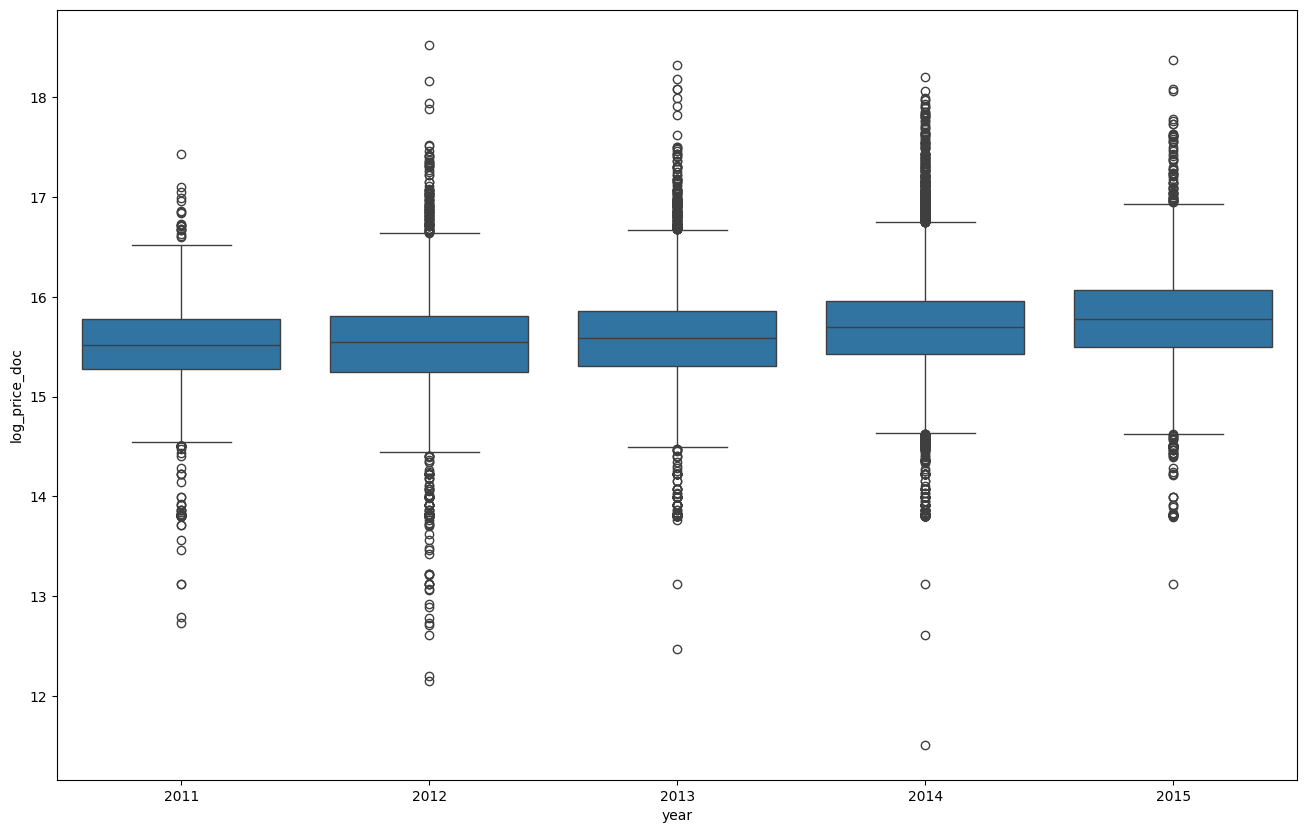

In [30]:
# Нарисуем графики распределения для некоторых фичей, 
# лучше проводить анализ сразу всех, но их слишком много чтобы анализировать в рамках лекции. 
# Посмотрим на распределение таргета по годам:

import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure()
fig.set_size_inches(16, 10)

sns.boxplot(y='log_price_doc', x=df['year'].astype('category'), data = df)

plt.show()

In [31]:
# Мы увидели что ящик с усами становится все больше (значит от года к году наша цена квартиры растет), 
# соответственно оставляем признак даты и кодируем его в OHE:

one_hot = pd.get_dummies(df['year'], prefix = 'year', drop_first = True)
df = pd.concat((df.drop('year', axis=1), one_hot), axis=1)

In [34]:
# Переводим булевые колонки в 0 и 1

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

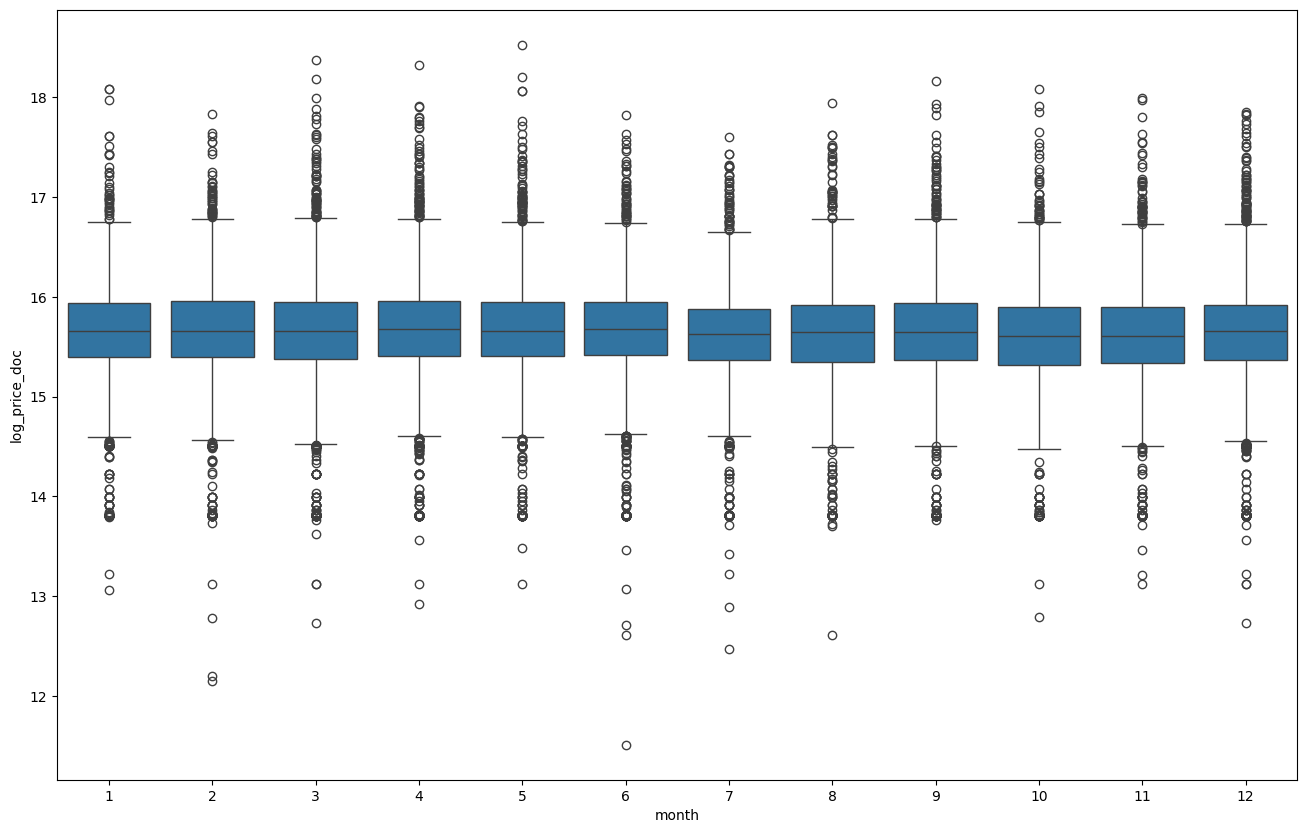

In [37]:
# Теперь посмотрим график ящика с усами по месяцам

fig = plt.figure()
fig.set_size_inches(16, 10)

sns.boxplot(y='log_price_doc', x=df['month'].astype('category'), data=df)

plt.show()

In [39]:
# Закодируем колонку с месяцем через OHE

one_hot = pd.get_dummies(df['month'], prefix='month', drop_first=True)
df = pd.concat((df.drop('month', axis=1), one_hot), axis=1)

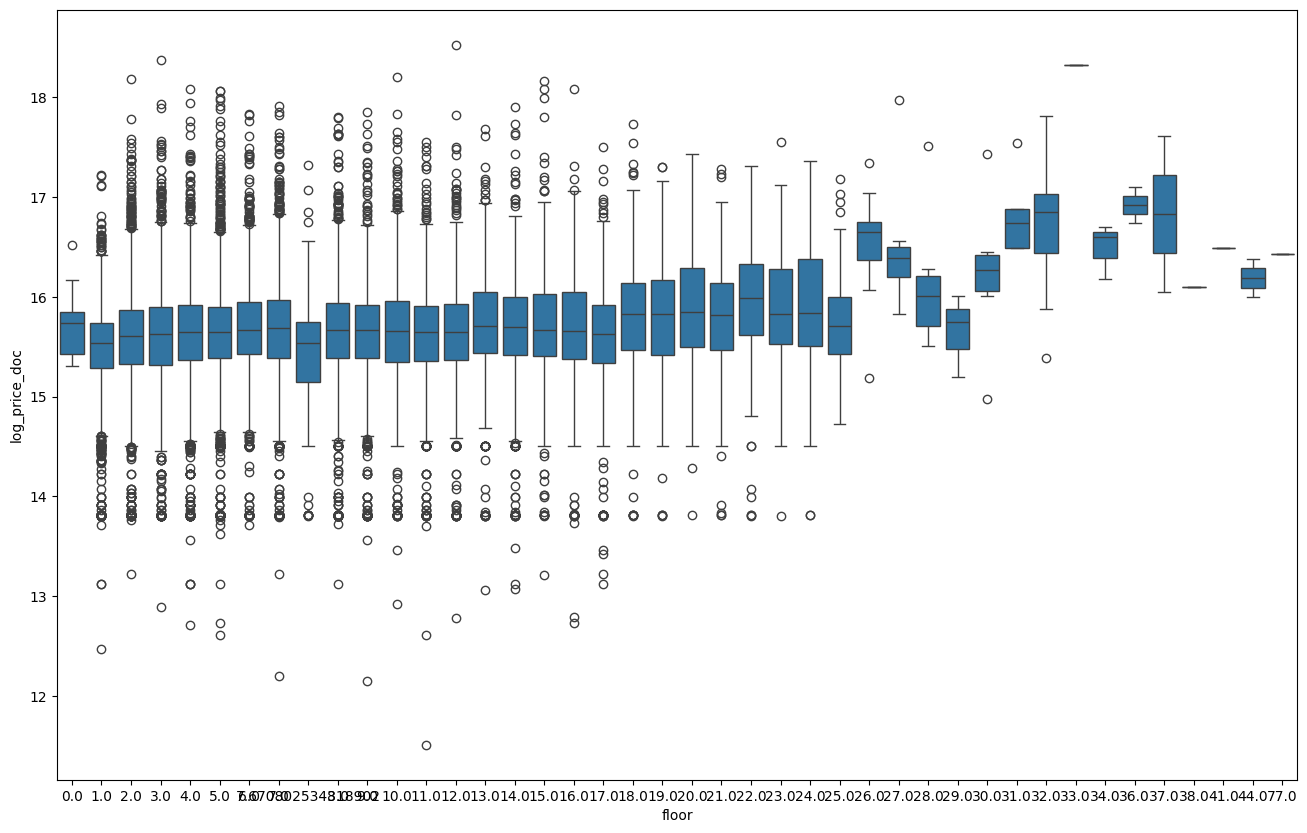

In [41]:
# Теперь посмотрим график распределения таргета по этажу

fig = plt.figure()
fig.set_size_inches(16, 10)

sns.boxplot(y='log_price_doc', x=df['floor'].astype('category'), data=df)

plt.show()

In [44]:
# уберем колонку timestamp

df = df.drop('timestamp', axis=1)

KeyError: "['timestamp'] not found in axis"

__ДЕЛИМ ВЫБОРКУ НА ТАРГЕТЫ И ОБЪЕКТЫ__

In [45]:
X = df.drop('log_price_doc', axis=1)
Y = df['log_price_doc']

In [48]:
X

,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,state,sub_area,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,43,27.000000,4.0,12.558974,1.827121,3068.057097,1.909804,6.399301,2.107025,15.594247,...,False,False,False,False,False,True,False,False,False,False
1,34,19.000000,3.0,12.558974,1.827121,3068.057097,1.909804,6.399301,2.107025,15.864842,...,False,False,False,False,False,True,False,False,False,False
2,43,29.000000,2.0,12.558974,1.827121,3068.057097,1.909804,6.399301,2.107025,15.613141,...,False,False,False,False,False,True,False,False,False,False
3,89,50.000000,9.0,12.558974,1.827121,3068.057097,1.909804,6.399301,2.107025,15.914449,...,False,False,False,False,False,False,True,False,False,False
4,77,77.000000,4.0,12.558974,1.827121,3068.057097,1.909804,6.399301,2.107025,16.091227,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30465,52,34.403271,13.0,17.000000,1.000000,3068.057097,2.000000,1.000000,1.000000,15.585972,...,False,False,False,True,False,False,False,False,False,False
30466,44,27.000000,7.0,9.000000,1.000000,1975.000000,2.000000,6.000000,3.000000,15.627701,...,False,False,False,True,False,False,False,False,False,False
30467,86,59.000000,3.0,9.000000,2.000000,1935.000000,4.000000,10.000000,3.000000,15.585972,...,False,False,False,True,False,False,False,False,False,False
30468,45,34.403271,10.0,20.000000,1.000000,3068.057097,1.000000,1.000000,1.000000,15.602230,...,False,False,False,True,False,False,False,False,False,False


In [49]:
Y

0        15.581952
1        15.607270
2        15.555977
3        16.388123
4        16.608603
           ...    
30465    15.725135
30466    15.816991
30467    17.034386
30468    15.757264
30470    15.538277
Name: log_price_doc, Length: 30471, dtype: float64

__Построение базовой модели, валидация__

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_validate
import numpy as np

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('Lasso', Lasso(max_iter=100000))
])

splitter = TimeSeriesSplit(n_splits=4)

alphas = np.linspace(0.01, 1, 30)		
param_grid = {'Lasso__alpha': alphas}	

search = GridSearchCV(pipe, param_grid, cv=splitter, scoring='neg_mean_squared_error')
search.fit(X, Y)

print(f"Лучший alpha: {search.best_params_}")
print(f"Лучший CV MSE: {(-search.best_score_).round(3)}")

best_model = search.best_estimator_

cv_result = cross_validate(best_model, X, Y, 
                           cv=splitter,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)

print(f"Среднее MSLE на трейне: {-np.mean(cv_result['train_score']).round(3)}")
print(f"Среднее MSLE на тесте: {-np.mean(cv_result['test_score']).round(3)}")

Лучший alpha: {'Lasso__alpha': np.float64(0.11241379310344828)}
Лучший CV MSE: 0.303
Среднее MSLE на трейне: 0.333
Среднее MSLE на тесте: 0.303


__Построим базовую модель без выбросов__

In [ ]:
# Создадим переменную и соединим X и Y в 1 датасет как раньше

data = pd.concat((X, Y), axis=1)
data

,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,state,sub_area,...,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,log_price_doc
0,43,27.000000,4.0,12.558974,1.827121,3068.057097,1.909804,6.399301,2.107025,15.594247,...,False,False,False,False,True,False,False,False,False,15.581952
1,34,19.000000,3.0,12.558974,1.827121,3068.057097,1.909804,6.399301,2.107025,15.864842,...,False,False,False,False,True,False,False,False,False,15.607270
2,43,29.000000,2.0,12.558974,1.827121,3068.057097,1.909804,6.399301,2.107025,15.613141,...,False,False,False,False,True,False,False,False,False,15.555977
3,89,50.000000,9.0,12.558974,1.827121,3068.057097,1.909804,6.399301,2.107025,15.914449,...,False,False,False,False,False,True,False,False,False,16.388123
4,77,77.000000,4.0,12.558974,1.827121,3068.057097,1.909804,6.399301,2.107025,16.091227,...,False,False,False,False,False,True,False,False,False,16.608603
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30465,52,34.403271,13.0,17.000000,1.000000,3068.057097,2.000000,1.000000,1.000000,15.585972,...,False,False,True,False,False,False,False,False,False,15.725135
30466,44,27.000000,7.0,9.000000,1.000000,1975.000000,2.000000,6.000000,3.000000,15.627701,...,False,False,True,False,False,False,False,False,False,15.816991
30467,86,59.000000,3.0,9.000000,2.000000,1935.000000,4.000000,10.000000,3.000000,15.585972,...,False,False,True,False,False,False,False,False,False,17.034386
30468,45,34.403271,10.0,20.000000,1.000000,3068.057097,1.000000,1.000000,1.000000,15.602230,...,False,False,True,False,False,False,False,False,False,15.757264


In [ ]:
# Посчитаем верхнюю и нижнюю грань усиков от ящика:

top_quantile = data['log_price_doc'].quantile(0.975)
low_quantile = data['log_price_doc'].quantile(0.025)

print(f'Топ 2.5% таргета {top_quantile.round(3)}')
print(f'Топ 97.5% таргета {low_quantile.round(3)}')

Топ 2.5% таргета 16.696
Топ 97.5% таргета 13.816


In [ ]:
# Оставим в датасете только данные между верхней и нижней частью избавившись от выбросов.

data = data[(data['log_price_doc'] > low_quantile) & ((data['log_price_doc'] < top_quantile))]

X_new, Y_new = data.drop('log_price_doc', axis=1), data['log_price_doc']

In [ ]:
# Стром базовую модель и обучаем на новых данных

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_validate
import numpy as np

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('Lasso', Lasso(max_iter=100000))
])

splitter = TimeSeriesSplit(n_splits=4)

alphas = np.linspace(0.01, 1, 30)		
param_grid = {'Lasso__alpha': alphas}	

search = GridSearchCV(pipe, param_grid, cv=splitter, scoring='neg_mean_squared_error')
search.fit(X_new, Y_new)

print(f"Лучший alpha: {search.best_params_}")
print(f"Лучший CV MSE: {(-search.best_score_).round(3)}")

best_model = search.best_estimator_

cv_result = cross_validate(best_model, X_new, Y_new, 
                           cv=splitter,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)

print(f"Среднее MSLE на трейне: {-np.mean(cv_result['train_score']).round(2)}")
print(f"Среднее MSLE на тесте: {-np.mean(cv_result['test_score']).round(2)}")

Лучший alpha: {'Lasso__alpha': np.float64(0.07827586206896552)}
Лучший CV MSE: 0.169
Среднее MSLE на трейне: 0.17
Среднее MSLE на тесте: 0.17


__Построим базовую модель с сигментацией данных__

In [112]:
# Разделим квартиры по типу недвижимости (вторичка и первичка)

Owner_Occupier = data[data['product_type_OwnerOccupier'] == 1].copy()
Investment = data[data['product_type_OwnerOccupier'] == 0].copy()

In [115]:
# Разделим на объекты и таргеты

X_Occupier = Owner_Occupier.drop('log_price_doc', axis = 1)
X_Investment = Investment.drop('log_price_doc', axis = 1)

Y_Occupier = Owner_Occupier['log_price_doc']
Y_Investment = Investment['log_price_doc']

In [116]:
# Соберем модель для Owner_Occupier

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_validate
import numpy as np

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('Lasso', Lasso(max_iter=100000))
])

splitter_new = TimeSeriesSplit(n_splits=4)

alphas = np.linspace(0.01, 1, 30)		
param_grid = {'Lasso__alpha': alphas}	

search = GridSearchCV(pipe, param_grid, cv=splitter_new, scoring='neg_mean_squared_error')
search.fit(X_Occupier, Y_Occupier)

print(f"Лучший alpha: {search.best_params_}")
print(f"Лучший CV MSE: {(-search.best_score_).round(3)}")

best_model = search.best_estimator_

cv_result = cross_validate(best_model, X_Occupier, Y_Occupier, 
                           cv=splitter_new,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)

print(f"Среднее MSLE на трейне: {-np.mean(cv_result['train_score']).round(2)}")
print(f"Среднее MSLE на тесте: {-np.mean(cv_result['test_score']).round(2)}")

Лучший alpha: {'Lasso__alpha': np.float64(0.04413793103448276)}
Лучший CV MSE: 0.082
Среднее MSLE на трейне: 0.07
Среднее MSLE на тесте: 0.08


In [117]:
# Соберем модель для Investment

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_validate
import numpy as np

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('Lasso', Lasso(max_iter=100000))
])

splitter_new2 = TimeSeriesSplit(n_splits=4)

alphas = np.linspace(0.01, 1, 30)		
param_grid = {'Lasso__alpha': alphas}	

search = GridSearchCV(pipe, param_grid, cv=splitter_new2, scoring='neg_mean_squared_error')
search.fit(X_Investment, Y_Investment)

print(f"Лучший alpha: {search.best_params_}")
print(f"Лучший CV MSE: {(-search.best_score_).round(3)}")

best_model = search.best_estimator_

cv_result = cross_validate(best_model, X_Investment, Y_Investment, 
                           cv=splitter_new2,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)

print(f"Среднее MSLE на трейне: {-np.mean(cv_result['train_score']).round(2)}")
print(f"Среднее MSLE на тесте: {-np.mean(cv_result['test_score']).round(2)}")

Лучший alpha: {'Lasso__alpha': np.float64(0.01)}
Лучший CV MSE: 0.175
Среднее MSLE на трейне: 0.18
Среднее MSLE на тесте: 0.18
